In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('1777260597.csv', sep=';')
df.head()

,Kode Provinsi,Nama Provinsi,Komoditas,Tahun,Bulan,Harga,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12
0,11,Aceh,Beras Premium,2021,Januari,Rp120.720,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,12,Sumatera Utara,Beras Premium,2021,Januari,Rp125.230,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,13,Sumatera Barat,Beras Premium,2021,Januari,Rp130.960,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,14,Riau,Beras Premium,2021,Januari,Rp146.050,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,15,Jambi,Beras Premium,2021,Januari,Rp123.230,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
col = ['Kode Provinsi', 'Nama Provinsi', 'Komoditas', 'Tahun', 'Bulan', 'Harga']

df = df[col]

In [4]:
df.head()

,Kode Provinsi,Nama Provinsi,Komoditas,Tahun,Bulan,Harga
0,11,Aceh,Beras Premium,2021,Januari,Rp120.720
1,12,Sumatera Utara,Beras Premium,2021,Januari,Rp125.230
2,13,Sumatera Barat,Beras Premium,2021,Januari,Rp130.960
3,14,Riau,Beras Premium,2021,Januari,Rp146.050
4,15,Jambi,Beras Premium,2021,Januari,Rp123.230


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37374 entries, 0 to 37373
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Kode Provinsi  37374 non-null  int64 
 1   Nama Provinsi  37374 non-null  object
 2   Komoditas      37374 non-null  object
 3   Tahun          37374 non-null  int64 
 4   Bulan          37374 non-null  object
 5   Harga          37374 non-null  object
dtypes: int64(2), object(4)
memory usage: 1.7+ MB


In [6]:
df['Kode Provinsi']= df['Kode Provinsi'].astype('category')
df['Harga'] = df['Harga'].str.replace('Rp', '', regex=False).str.strip()
df['Harga'] = df['Harga'].str.replace(',', '', regex=False)
df['Harga'] = pd.to_numeric(df['Harga'], errors='coerce') * 100

In [15]:
df['Tahun'] = df['Tahun'].astype('category')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37374 entries, 0 to 37373
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   Kode Provinsi  37374 non-null  category
 1   Nama Provinsi  37374 non-null  object  
 2   Komoditas      37374 non-null  object  
 3   Tahun          37374 non-null  int64   
 4   Bulan          37374 non-null  object  
 5   Harga          34629 non-null  float64 
dtypes: category(1), float64(1), int64(1), object(3)
memory usage: 1.5+ MB


In [10]:
df.isna().sum()

Kode Provinsi       0
Nama Provinsi       0
Komoditas           0
Tahun               0
Bulan               0
Harga            2745
dtype: int64

In [47]:
data_null = df[df.isna().any(axis=1)]
data_null.sample(5)

,Kode Provinsi,Nama Provinsi,Komoditas,Tahun,Bulan,Harga
13306,33,JAWA TENGAH,Daging Sapi Murni,2023,september,NaN
2714,75,GORONTALO,Daging Sapi Murni,2021,juli,NaN
9633,32,JAWA BARAT,Daging Sapi Murni,2022,desember,NaN
8835,76,SULAWESI BARAT,Daging Sapi Murni,2022,oktober,NaN
28976,11,ACEH,Daging Sapi Murni,2025,juni,NaN


In [48]:
cats = ['Kode Provinsi', 'Nama Provinsi', 'Komoditas', 'Tahun', 'Bulan']
data_null[cats].describe().T

,count,unique,top,freq
Kode Provinsi,2745,38,95,112
Nama Provinsi,2745,38,PAPUA PEGUNUNGAN,112
Komoditas,2745,27,Daging Sapi Murni,1958
Tahun,2745,6,2025,785
Bulan,2745,12,februari,422


In [30]:
df['Nama Provinsi'].describe()

count     37374
unique       77
top        Aceh
freq        725
Name: Nama Provinsi, dtype: object

In [31]:
# 1. Ubah jadi huruf besar semua dan hilangkan spasi di ujung teks
df['Nama Provinsi'] = df['Nama Provinsi'].str.upper().str.strip()

# 2. Cek kembali jumlah provinsinya sekarang
print(df['Nama Provinsi'].value_counts())

Nama Provinsi
ACEH                         1029
SUMATERA UTARA               1029
SUMATERA BARAT               1029
RIAU                         1029
JAMBI                        1029
SUMATERA SELATAN             1029
BENGKULU                     1029
LAMPUNG                      1029
KEPULAUAN BANGKA BELITUNG    1029
KEPULAUAN RIAU               1029
DKI JAKARTA                  1029
JAWA BARAT                   1029
JAWA TENGAH                  1029
JAWA TIMUR                   1029
BANTEN                       1029
KALIMANTAN BARAT             1029
BALI                         1029
NUSA TENGGARA BARAT          1029
NUSA TENGGARA TIMUR          1029
KALIMANTAN SELATAN           1029
KALIMANTAN TENGAH            1029
KALIMANTAN TIMUR             1029
KALIMANTAN UTARA             1029
MALUKU UTARA                 1029
SULAWESI UTARA               1029
SULAWESI TENGAH              1029
SULAWESI SELATAN             1029
SULAWESI TENGGARA            1029
GORONTALO                    1029


In [36]:
df['Nama Provinsi'].unique()

array(['ACEH', 'SUMATERA UTARA', 'SUMATERA BARAT', 'RIAU', 'JAMBI',
       'SUMATERA SELATAN', 'BENGKULU', 'LAMPUNG',
       'KEPULAUAN BANGKA BELITUNG', 'KEPULAUAN RIAU', 'DKI JAKARTA',
       'JAWA BARAT', 'JAWA TENGAH', 'DI YOGYAKARTA', 'JAWA TIMUR',
       'BANTEN', 'BALI', 'NUSA TENGGARA BARAT', 'NUSA TENGGARA TIMUR',
       'KALIMANTAN BARAT', 'KALIMANTAN TENGAH', 'KALIMANTAN SELATAN',
       'KALIMANTAN TIMUR', 'KALIMANTAN UTARA', 'SULAWESI UTARA',
       'SULAWESI TENGAH', 'SULAWESI SELATAN', 'SULAWESI TENGGARA',
       'GORONTALO', 'SULAWESI BARAT', 'MALUKU', 'MALUKU UTARA',
       'PAPUA BARAT', 'PAPUA', 'PAPUA BARAT DAYA', 'PAPUA SELATAN',
       'PAPUA TENGAH', 'PAPUA PEGUNUNGAN', 'D.I YOGYAKARTA'], dtype=object)

In [ ]:
df['Nama Provinsi'] = df['Nama Provinsi'].replace('D.I YOGYAKARTA', 'DI YOGYAKARTA')

# Cek kembali hasilnya
print(df['Nama Provinsi'].unique())

['ACEH' 'SUMATERA UTARA' 'SUMATERA BARAT' 'RIAU' 'JAMBI'
 'SUMATERA SELATAN' 'BENGKULU' 'LAMPUNG' 'KEPULAUAN BANGKA BELITUNG'
 'KEPULAUAN RIAU' 'DKI JAKARTA' 'JAWA BARAT' 'JAWA TENGAH' 'DI YOGYAKARTA'
 'JAWA TIMUR' 'BANTEN' 'BALI' 'NUSA TENGGARA BARAT' 'NUSA TENGGARA TIMUR'
 'KALIMANTAN BARAT' 'KALIMANTAN TENGAH' 'KALIMANTAN SELATAN'
 'KALIMANTAN TIMUR' 'KALIMANTAN UTARA' 'SULAWESI UTARA' 'SULAWESI TENGAH'
 'SULAWESI SELATAN' 'SULAWESI TENGGARA' 'GORONTALO' 'SULAWESI BARAT'
 'MALUKU' 'MALUKU UTARA' 'PAPUA BARAT' 'PAPUA' 'PAPUA BARAT DAYA'
 'PAPUA SELATAN' 'PAPUA TENGAH' 'PAPUA PEGUNUNGAN']


In [38]:
len(df['Nama Provinsi'].unique())

38

In [39]:
df.sample(10)

,Kode Provinsi,Nama Provinsi,Komoditas,Tahun,Bulan,Harga
6304,35,JAWA TIMUR,Cabai Merah Keriting,2022,April,32769.0
12783,94,PAPUA,Bawang Merah,2023,Agustus,56535.0
14933,52,NUSA TENGGARA BARAT,Cabai Rawit Merah,2024,Januari,41845.0
36324,35,JAWA TIMUR,Daging Kerbau Segar (Lokal),2026,Januari,120.0
33900,64,KALIMANTAN TIMUR,Minyak Goreng Kemasan,2025,November,21975.0
27620,33,JAWA TENGAH,Minyak Kita,2025,April,16969.0
5734,64,KALIMANTAN TIMUR,Beras Premium,2022,Maret,13255.0
30580,19,KEPULAUAN BANGKA BELITUNG,Beras SPHP,2025,Agustus,12483.0
1562,91,PAPUA BARAT,Telur Ayam Ras,2021,April,30212.0
4361,21,KEPULAUAN RIAU,Daging Ayam Ras,2021,November,38646.0


In [43]:
df['Bulan'].unique()

array(['Januari', 'Februari', 'Maret', 'April', 'Mei', 'Juni', 'Juli',
       'Agustus', 'September', 'Oktober', 'November', 'Desember',
       'Maret ', 'April ', 'Juni ', 'November ', 'Januari '], dtype=object)

In [44]:
df['Bulan'] = df['Bulan'].str.lower().str.strip()

In [49]:
df['Tahun'].unique()

[2021, 2022, 2023, 2024, 2025, 2026]
Categories (6, int64): [2021, 2022, 2023, 2024, 2025, 2026]

In [50]:
daging_sapi = df[df['Komoditas']=='Daging Sapi Murni']

In [53]:
daging_sapi[cats].describe().T

,count,unique,top,freq
Kode Provinsi,2212,38,11,62
Nama Provinsi,2212,38,ACEH,62
Komoditas,2212,1,Daging Sapi Murni,2212
Tahun,2212,6,2025,456
Bulan,2212,12,januari,216


In [56]:
daging_sapi_null = daging_sapi[daging_sapi.isna().any(axis=1)]
daging_sapi_null[cats].describe().T

,count,unique,top,freq
Kode Provinsi,1958,38,12,61
Nama Provinsi,1958,38,SUMATERA UTARA,61
Komoditas,1958,1,Daging Sapi Murni,1958
Tahun,1958,6,2025,408
Bulan,1958,12,februari,195


<Axes: xlabel='Tahun', ylabel='count'>

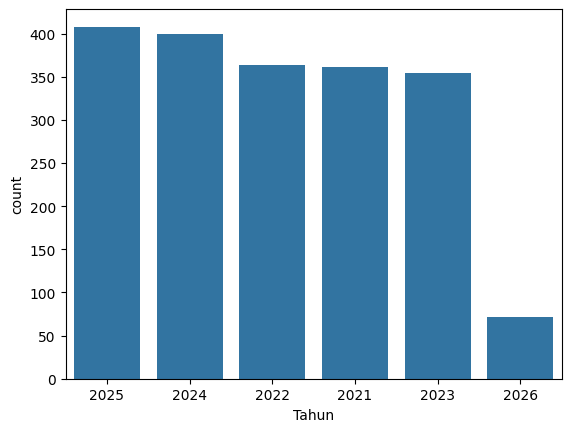

In [57]:
sns.countplot(data=daging_sapi_null, x='Tahun', order=daging_sapi_null['Tahun'].value_counts().index)

In [63]:
data_null['Bulan'].value_counts()

Bulan
februari     422
januari      336
maret        298
mei          197
juli         194
juni         193
agustus      191
desember     190
oktober      183
april        181
september    181
november     179
Name: count, dtype: int64

In [72]:
tahun_26 = df[df['Tahun']==2026]

In [73]:
tahun_26

,Kode Provinsi,Nama Provinsi,Komoditas,Tahun,Bulan,Harga
35322,11,ACEH,Beras SPHP,2026,januari,12757.0
35323,12,SUMATERA UTARA,Beras SPHP,2026,januari,12774.0
35324,13,SUMATERA BARAT,Beras SPHP,2026,januari,1286.0
35325,14,RIAU,Beras SPHP,2026,januari,12865.0
35326,15,JAMBI,Beras SPHP,2026,januari,12488.0
...,...,...,...,...,...,...
37369,92,PAPUA BARAT,Daging Kerbau Segar (Lokal),2026,februari,NaN
37370,93,PAPUA SELATAN,Daging Kerbau Segar (Lokal),2026,februari,140.0
37371,94,PAPUA TENGAH,Daging Kerbau Segar (Lokal),2026,februari,NaN
37372,95,PAPUA PEGUNUNGAN,Daging Kerbau Segar (Lokal),2026,februari,NaN


In [74]:
tahun_26['Bulan'].value_counts()

Bulan
januari     1026
februari    1026
Name: count, dtype: int64

In [75]:
print(df.shape)
print(df.columns.tolist())
print(df.head())
print(df.dtypes)

(37374, 6)
['Kode Provinsi', 'Nama Provinsi', 'Komoditas', 'Tahun', 'Bulan', 'Harga']
  Kode Provinsi   Nama Provinsi      Komoditas Tahun    Bulan    Harga
0            11            ACEH  Beras Premium  2021  januari  12072.0
1            12  SUMATERA UTARA  Beras Premium  2021  januari  12523.0
2            13  SUMATERA BARAT  Beras Premium  2021  januari  13096.0
3            14            RIAU  Beras Premium  2021  januari  14605.0
4            15           JAMBI  Beras Premium  2021  januari  12323.0
Kode Provinsi    category
Nama Provinsi      object
Komoditas          object
Tahun            category
Bulan              object
Harga             float64
dtype: object


In [ ]:
#Mapping bulan Indonesia ke angka
bulan_map = {
    'januari': 1, 'februari': 2, 'maret': 3, 'april': 4,
    'mei': 5, 'juni': 6, 'juli': 7, 'agustus': 8,
    'september': 9, 'oktober': 10, 'november': 11, 'desember': 12
}

df['Bulan_num'] = df['Bulan'].str.lower().map(bulan_map)


df['Periode'] = pd.to_datetime(
    df['Tahun'].astype(str) + '-' + df['Bulan_num'].astype(str),
    format='%Y-%m'
)

# Step 3: Verifikasi
print(df[['Tahun', 'Bulan', 'Periode']].head(10))
print(df['Periode'].dtype)

  Tahun    Bulan    Periode
0  2021  januari 2021-01-01
1  2021  januari 2021-01-01
2  2021  januari 2021-01-01
3  2021  januari 2021-01-01
4  2021  januari 2021-01-01
5  2021  januari 2021-01-01
6  2021  januari 2021-01-01
7  2021  januari 2021-01-01
8  2021  januari 2021-01-01
9  2021  januari 2021-01-01
datetime64[ns]


In [77]:
# Rata-rata harga semua komoditas per provinsi per periode
inflasi_df = df.groupby(['Nama Provinsi', 'Periode'])['Harga'].mean().reset_index()
inflasi_df.columns = ['Nama Provinsi', 'Periode', 'Rata_Harga']

# Cek hasilnya
print(inflasi_df.shape)
print(inflasi_df.head(10))

(2212, 3)
  Nama Provinsi    Periode    Rata_Harga
0          ACEH 2021-01-01  22401.000000
1          ACEH 2021-02-01  23326.454545
2          ACEH 2021-03-01  21214.727273
3          ACEH 2021-04-01  15520.900000
4          ACEH 2021-05-01  23572.090909
5          ACEH 2021-06-01  16562.083333
6          ACEH 2021-07-01  14795.800000
7          ACEH 2021-08-01  22495.272727
8          ACEH 2021-09-01  20310.636364
9          ACEH 2021-10-01  17355.818182


In [78]:
# Sort dulu biar rapi
inflasi_df = inflasi_df.sort_values(['Nama Provinsi', 'Periode']).reset_index(drop=True)

# Harga tahun sebelumnya (shift 12 bulan per provinsi)
inflasi_df['Harga_Tahun_Lalu'] = inflasi_df.groupby('Nama Provinsi')['Rata_Harga'].shift(12)

# Hitung YoY %
inflasi_df['YoY_%'] = (
    (inflasi_df['Rata_Harga'] - inflasi_df['Harga_Tahun_Lalu']) 
    / inflasi_df['Harga_Tahun_Lalu'] * 100
).round(2)

# Cek hasilnya
print(inflasi_df.dropna().head(10))

   Nama Provinsi    Periode    Rata_Harga  Harga_Tahun_Lalu   YoY_%
12          ACEH 2022-01-01  20637.454545      22401.000000   -7.87
13          ACEH 2022-02-01  21022.090909      23326.454545   -9.88
14          ACEH 2022-03-01  20613.090909      21214.727273   -2.84
15          ACEH 2022-04-01  20075.100000      15520.900000   29.34
16          ACEH 2022-05-01  19544.400000      23572.090909  -17.09
17          ACEH 2022-06-01  29607.090909      16562.083333   78.76
18          ACEH 2022-07-01  34051.916667      14795.800000  130.15
19          ACEH 2022-08-01  22922.100000      22495.272727    1.90
20          ACEH 2022-09-01  27556.500000      20310.636364   35.68
21          ACEH 2022-10-01  23740.181818      17355.818182   36.79


In [79]:
# Bandingkan rata-rata harga 2021 vs 2025 per provinsi
harga_2021 = inflasi_df[inflasi_df['Periode'].dt.year == 2021].groupby('Nama Provinsi')['Rata_Harga'].mean()
harga_2025 = inflasi_df[inflasi_df['Periode'].dt.year == 2025].groupby('Nama Provinsi')['Rata_Harga'].mean()

ringkasan = pd.DataFrame({
    'Harga_2021': harga_2021,
    'Harga_2025': harga_2025
}).dropna()

ringkasan['Inflasi_Total_%'] = ((ringkasan['Harga_2025'] - ringkasan['Harga_2021']) / ringkasan['Harga_2021'] * 100).round(2)
ringkasan = ringkasan.sort_values('Inflasi_Total_%', ascending=False)

print(ringkasan)

                             Harga_2021    Harga_2025  Inflasi_Total_%
Nama Provinsi                                                         
SUMATERA BARAT             19523.669697  24945.655495            27.77
BANTEN                     20685.256187  25319.006399            22.40
ACEH                       19710.526641  23318.517507            18.30
DKI JAKARTA                23401.052399  26681.188453            14.02
SULAWESI BARAT             18551.013258  20511.145391            10.57
NUSA TENGGARA BARAT        20205.600379  22313.498548            10.43
SULAWESI SELATAN           18731.780303  20614.124309            10.05
RIAU                       21229.164141  23055.726298             8.60
JAWA TENGAH                20327.332071  22049.274798             8.47
SULAWESI TENGGARA          21990.606061  23784.399192             8.16
SUMATERA SELATAN           19990.327020  21603.132323             8.07
DI YOGYAKARTA              19881.995581  21475.642399             8.02
JAMBI 

In [80]:
# Berapa komoditas yang tercatat per provinsi per tahun?
coverage = df.dropna(subset=['Harga']).groupby(
    ['Nama Provinsi', df['Periode'].dt.year]
)['Komoditas'].nunique().reset_index()

coverage.columns = ['Nama Provinsi', 'Tahun', 'Jumlah_Komoditas']

# Lihat provinsi yang deflasi ekstrem
provinsi_deflasi = ['KEPULAUAN RIAU', 'MALUKU UTARA', 'MALUKU', 'GORONTALO', 'SULAWESI TENGAH']
print(coverage[coverage['Nama Provinsi'].isin(provinsi_deflasi)].pivot(
    index='Nama Provinsi', columns='Tahun', values='Jumlah_Komoditas'
))

Tahun            2021  2022  2023  2024  2025  2026
Nama Provinsi                                      
GORONTALO          11    12    12    21    25    22
KEPULAUAN RIAU     12    12    11    21    25    24
MALUKU             12    12    12    21    25    24
MALUKU UTARA       11    12    12    21    25    23
SULAWESI TENGAH    12    12    12    21    25    24


In [81]:
# Cek komoditas apa saja yang ada di setiap tahun per provinsi
komoditas_per_tahun = df.dropna(subset=['Harga']).groupby(
    ['Komoditas', df['Periode'].dt.year]
)['Nama Provinsi'].count().unstack()

print(komoditas_per_tahun)

Periode                       2021   2022   2023   2024   2025  2026
Komoditas                                                           
Bawang Merah                 408.0  408.0  407.0  456.0  452.0  74.0
Bawang Putih (Bonggol)       408.0  408.0  407.0  456.0  452.0  74.0
Beras Khusus (Lokal)           NaN    NaN    NaN    NaN    NaN  65.0
Beras Medium                 408.0  408.0  407.0  456.0  453.0  74.0
Beras Medium Non SPHP          NaN    NaN    NaN    NaN    NaN  74.0
Beras Premium                408.0  408.0  407.0  456.0  452.0  72.0
Beras SPHP                     NaN    NaN    NaN  257.0  449.0  74.0
Cabai Merah Besar              NaN    NaN    NaN    NaN  411.0  71.0
Cabai Merah Keriting         408.0  408.0  407.0  452.0  452.0  74.0
Cabai Rawit Merah            383.0  395.0  395.0  441.0  426.0  73.0
Daging Ayam Ras              408.0  408.0  407.0  456.0  453.0  74.0
Daging Kerbau Beku (Impor)     NaN    NaN    NaN    NaN  299.0   8.0
Daging Kerbau Segar (Lokal)    NaN

In [82]:
komoditas_core = [
    'Bawang Merah', 'Bawang Putih (Bonggol)', 'Beras Medium',
    'Beras Premium', 'Cabai Merah Keriting', 'Cabai Rawit Merah',
    'Daging Ayam Ras', 'Gula Pasir Lokal/Curah', 'Kedelai Biji Kering',
    'Minyak Goreng Kemasan', 'Telur Ayam Ras'
]

# Filter dataframe hanya komoditas core, dan hanya tahun 2021-2025
df_core = df[
    (df['Komoditas'].isin(komoditas_core)) &
    (df['Periode'].dt.year.isin([2021, 2022, 2023, 2024, 2025]))
].copy()

print(df_core.shape)
print(df_core['Komoditas'].value_counts())

(23496, 8)
Komoditas
Beras Premium             2136
Beras Medium              2136
Kedelai Biji Kering       2136
Bawang Merah              2136
Bawang Putih (Bonggol)    2136
Cabai Merah Keriting      2136
Cabai Rawit Merah         2136
Daging Ayam Ras           2136
Telur Ayam Ras            2136
Gula Pasir Lokal/Curah    2136
Minyak Goreng Kemasan     2136
Name: count, dtype: int64


In [83]:
# Agregasi ulang dengan data core
inflasi_core = df_core.groupby(['Nama Provinsi', 'Periode'])['Harga'].mean().reset_index()
inflasi_core.columns = ['Nama Provinsi', 'Periode', 'Rata_Harga']

# Bandingkan 2021 vs 2025
harga_2021 = inflasi_core[inflasi_core['Periode'].dt.year == 2021].groupby('Nama Provinsi')['Rata_Harga'].mean()
harga_2025 = inflasi_core[inflasi_core['Periode'].dt.year == 2025].groupby('Nama Provinsi')['Rata_Harga'].mean()

ringkasan_core = pd.DataFrame({
    'Harga_2021': harga_2021,
    'Harga_2025': harga_2025
}).dropna()

ringkasan_core['Inflasi_Total_%'] = (
    (ringkasan_core['Harga_2025'] - ringkasan_core['Harga_2021']) 
    / ringkasan_core['Harga_2021'] * 100
).round(2)

ringkasan_core = ringkasan_core.sort_values('Inflasi_Total_%', ascending=False)
print(ringkasan_core)

                             Harga_2021    Harga_2025  Inflasi_Total_%
Nama Provinsi                                                         
DKI JAKARTA                23579.284091  34986.607576            48.38
BANTEN                     20816.112879  29034.977273            39.48
SUMATERA BARAT             19710.631818  27319.780303            38.60
SULAWESI BARAT             18905.931818  25908.128788            37.04
SULAWESI TENGGARA          21990.606061  29396.272727            33.68
SUMATERA SELATAN           20021.015152  26546.840909            32.59
ACEH                       19767.440909  26105.395455            32.06
NUSA TENGGARA BARAT        20361.655303  26880.981061            32.02
RIAU                       21436.590909  28170.825758            31.41
KALIMANTAN UTARA           26448.428788  34392.494697            30.04
DI YOGYAKARTA              20018.196970  25703.446970            28.40
SULAWESI SELATAN           18731.780303  24050.272727            28.39
BALI  

In [84]:
# Cek inflasi per komoditas — komoditas mana yang paling berkontribusi?
inflasi_komoditas = df_core.groupby(['Komoditas', df_core['Periode'].dt.year])['Harga'].mean().unstack()

inflasi_komoditas['Inflasi_%'] = (
    (inflasi_komoditas[2025] - inflasi_komoditas[2021]) 
    / inflasi_komoditas[2021] * 100
).round(2)

print(inflasi_komoditas[['Inflasi_%']].sort_values('Inflasi_%', ascending=False))

Periode                 Inflasi_%
Komoditas                        
Minyak Goreng Kemasan       45.25
Bawang Putih (Bonggol)      44.90
Bawang Merah                40.65
Gula Pasir Lokal/Curah      36.48
Cabai Merah Keriting        33.33
Beras Medium                30.59
Telur Ayam Ras              28.53
Beras Premium               28.45
Kedelai Biji Kering          6.61
Daging Ayam Ras              5.61
Cabai Rawit Merah            1.99


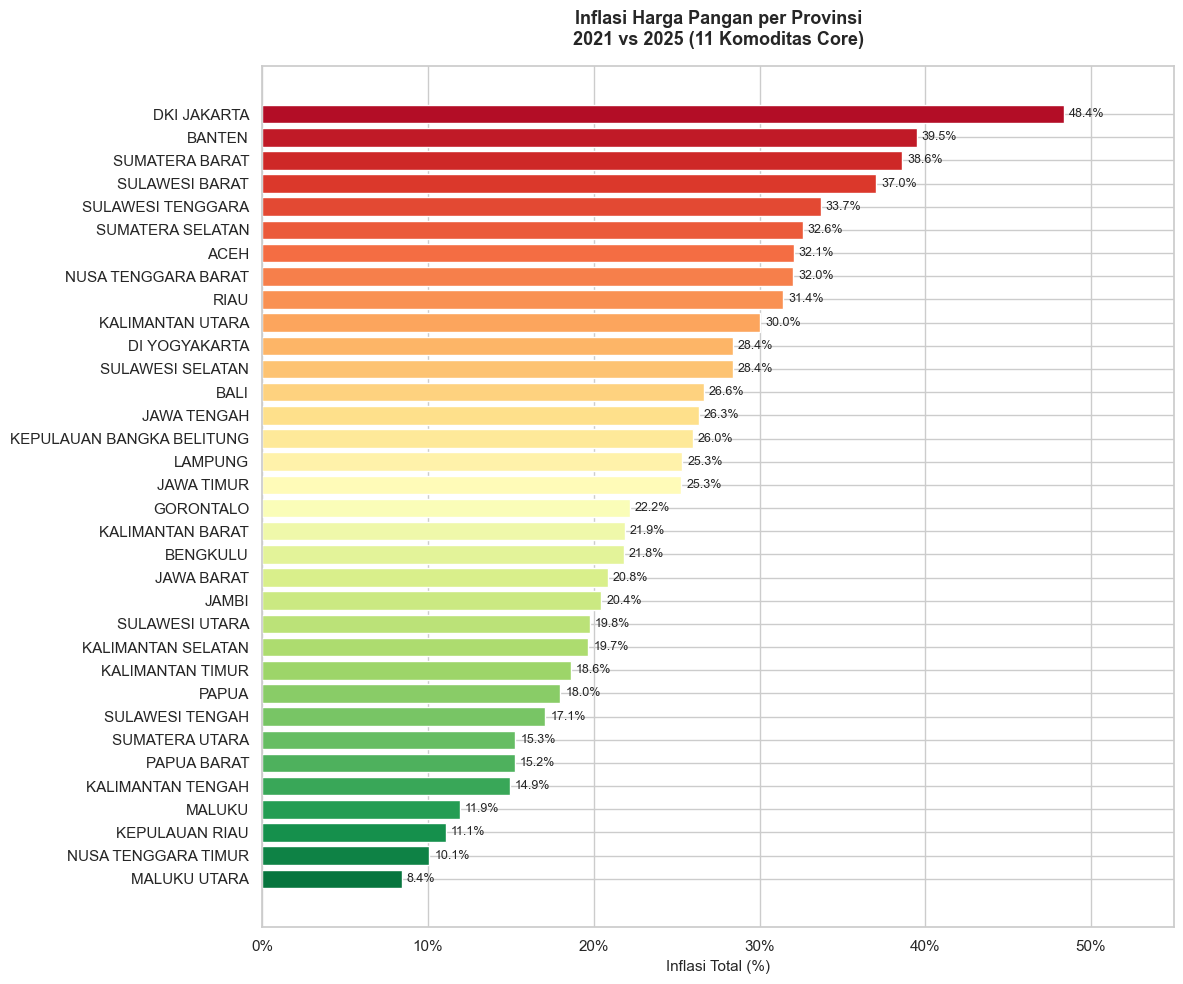

In [85]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

# Setup style
sns.set_theme(style='whitegrid', font='sans-serif')

# Warna — merah untuk tinggi, hijau untuk rendah
colors = sns.color_palette('RdYlGn_r', n_colors=len(ringkasan_core))

fig, ax = plt.subplots(figsize=(12, 10))

bars = ax.barh(
    ringkasan_core.sort_values('Inflasi_Total_%').index,
    ringkasan_core.sort_values('Inflasi_Total_%')['Inflasi_Total_%'],
    color=colors
)

# Label nilai di ujung bar
for bar, val in zip(bars, ringkasan_core.sort_values('Inflasi_Total_%')['Inflasi_Total_%']):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)

ax.set_xlabel('Inflasi Total (%)', fontsize=11)
ax.set_title('Inflasi Harga Pangan per Provinsi\n2021 vs 2025 (11 Komoditas Core)',
             fontsize=13, fontweight='bold', pad=15)
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlim(0, 55)

plt.tight_layout()
plt.savefig('chart1_inflasi_provinsi.png', dpi=150, bbox_inches='tight')
plt.show()

C:\TEMP\Temp\ipykernel_4136\3614080873.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(inflasi_kom_sorted.index, rotation=30, ha='right', fontsize=9)


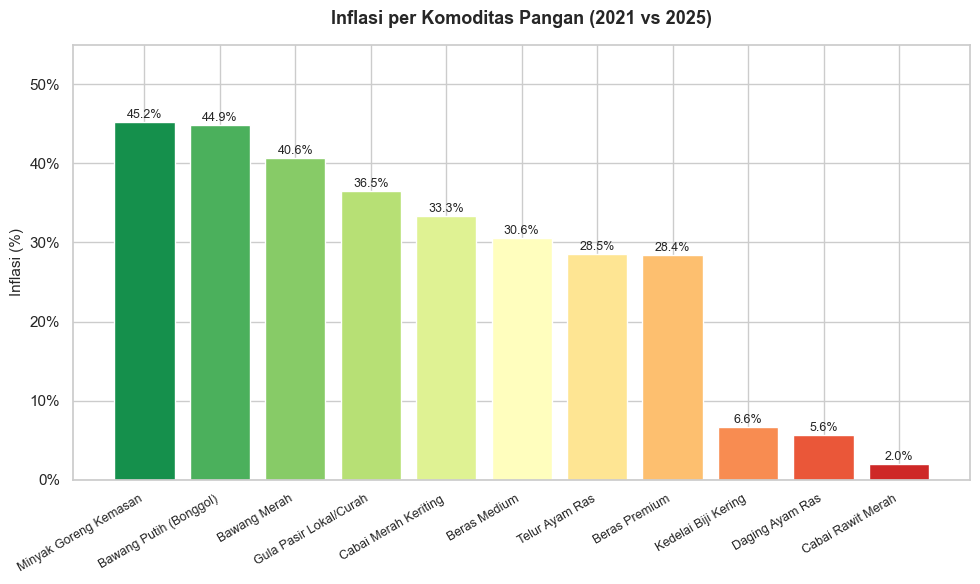

In [86]:
# ── Inflasi per Komoditas ─────────────────────────────────────────
inflasi_kom_sorted = inflasi_komoditas['Inflasi_%'].sort_values(ascending=False)
colors2 = sns.color_palette('RdYlGn_r', n_colors=len(inflasi_kom_sorted))

fig, ax = plt.subplots(figsize=(10, 6))
bars2 = ax.bar(inflasi_kom_sorted.index, inflasi_kom_sorted.values, color=colors2)

for bar, val in zip(bars2, inflasi_kom_sorted.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.5,
            f'{val:.1f}%', ha='center', fontsize=9)

ax.set_ylabel('Inflasi (%)', fontsize=11)
ax.set_title('Inflasi per Komoditas Pangan (2021 vs 2025)',
             fontsize=13, fontweight='bold', pad=15)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xticklabels(inflasi_kom_sorted.index, rotation=30, ha='right', fontsize=9)
ax.set_ylim(0, 55)
plt.tight_layout()
plt.savefig('chart2_inflasi_komoditas.png', dpi=150, bbox_inches='tight')
plt.show()

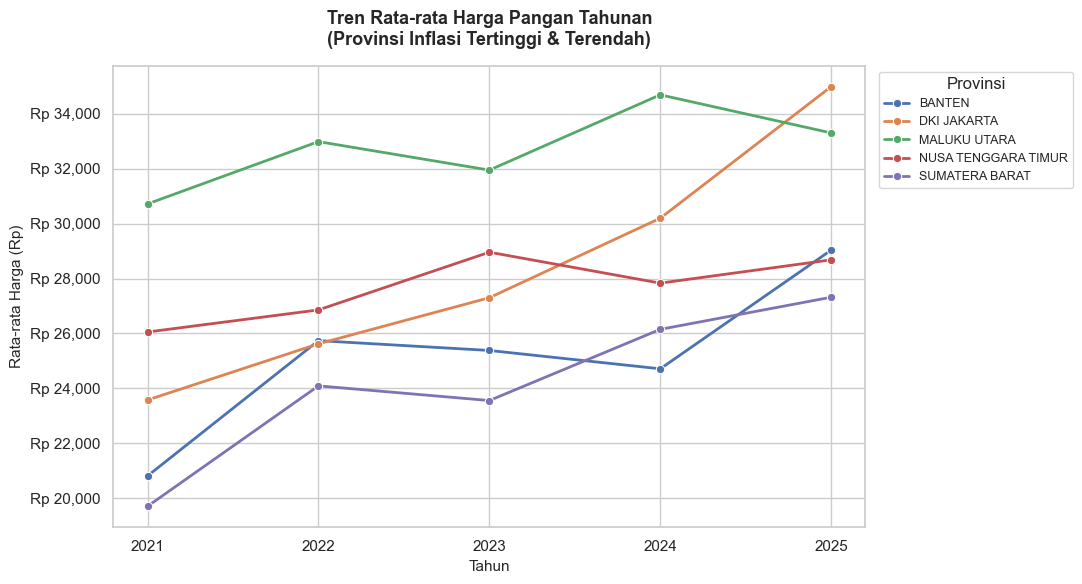

In [87]:
provinsi_pilihan = ['DKI JAKARTA', 'BANTEN', 'SUMATERA BARAT', 'MALUKU UTARA', 'NUSA TENGGARA TIMUR']

tren = inflasi_core[inflasi_core['Nama Provinsi'].isin(provinsi_pilihan)].copy()
tren['Tahun'] = tren['Periode'].dt.year
tren_tahunan = tren.groupby(['Nama Provinsi', 'Tahun'])['Rata_Harga'].mean().reset_index()

fig, ax = plt.subplots(figsize=(11, 6))
sns.lineplot(data=tren_tahunan, x='Tahun', y='Rata_Harga',
             hue='Nama Provinsi', marker='o', linewidth=2, ax=ax)

ax.set_title('Tren Rata-rata Harga Pangan Tahunan\n(Provinsi Inflasi Tertinggi & Terendah)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_ylabel('Rata-rata Harga (Rp)', fontsize=11)
ax.set_xlabel('Tahun', fontsize=11)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'Rp {x:,.0f}'))
ax.legend(title='Provinsi', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.set_xticks([2021, 2022, 2023, 2024, 2025])
plt.tight_layout()
plt.savefig('chart3_tren_harga.png', dpi=150, bbox_inches='tight')
plt.show()

In [90]:
# ── CHART 4: Heatmap Inflasi Komoditas per Provinsi ────────────────────────
heatmap_data = df_core.groupby(['Nama Provinsi', 'Komoditas', df_core['Periode'].dt.year])['Harga'].mean().unstack()
heatmap_inflasi = ((heatmap_data[2025] - heatmap_data[2021]) / heatmap_data[2021] * 100).round(1)

# Cek bentuknya dulu
print(type(heatmap_inflasi))
print(heatmap_inflasi.shape)
print(heatmap_inflasi.head())

<class 'pandas.core.series.Series'>
(418,)
Nama Provinsi  Komoditas             
ACEH           Bawang Merah              28.1
               Bawang Putih (Bonggol)    41.1
               Beras Medium              28.1
               Beras Premium             27.9
               Cabai Merah Keriting      57.8
dtype: float64


(38, 11)


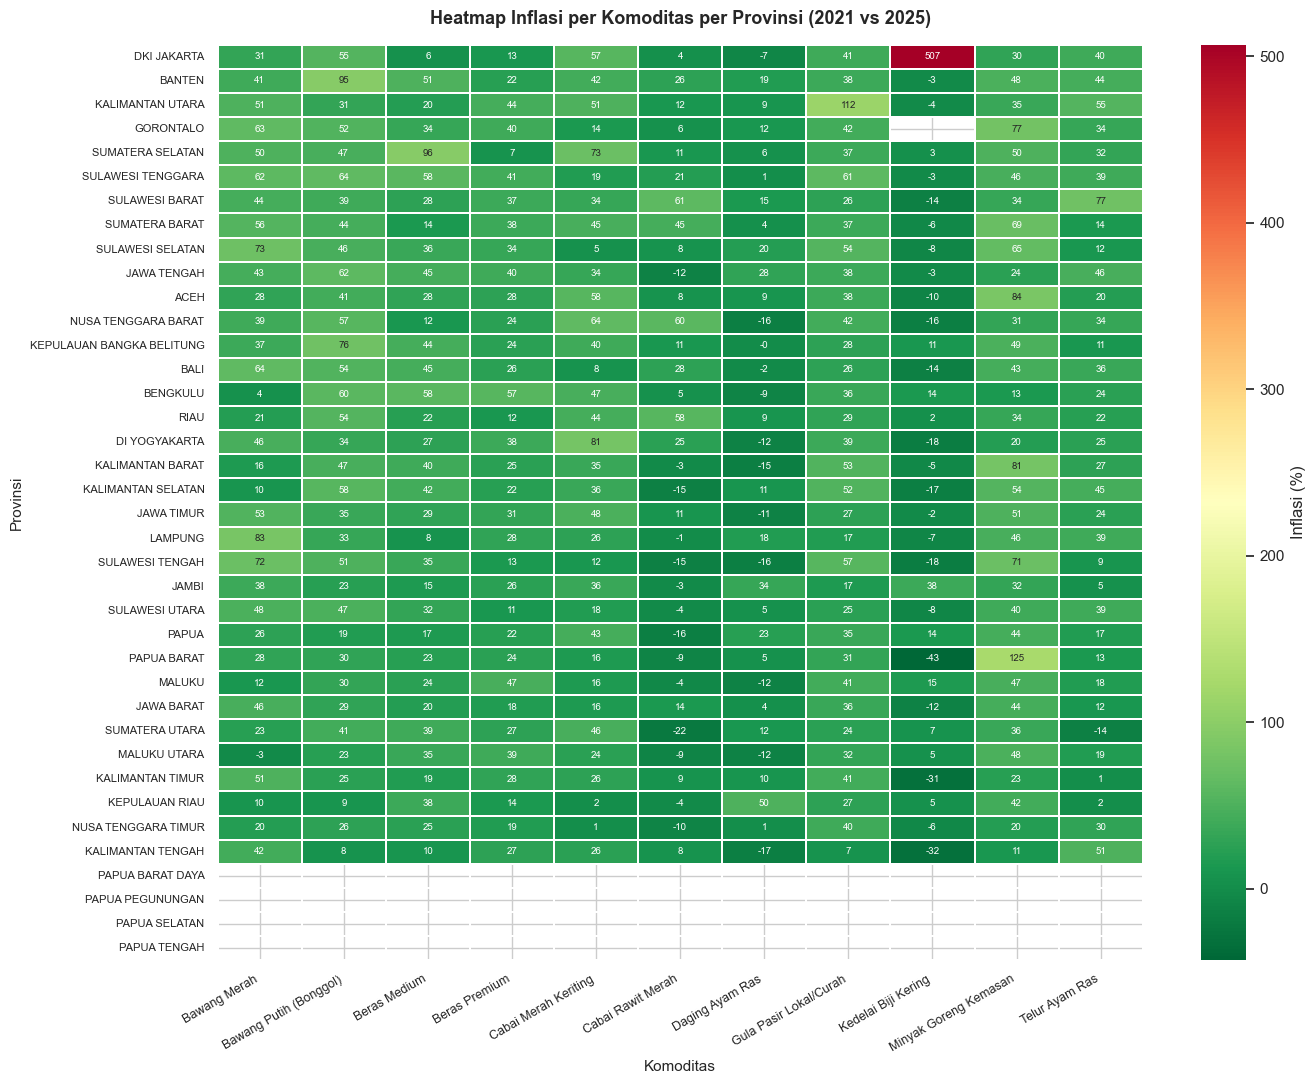

In [93]:
# ── CHART 4: Heatmap Inflasi Komoditas per Provinsi ────────────────────────

harga_pivot = df_core.groupby(['Nama Provinsi', 'Komoditas', df_core['Periode'].dt.year])['Harga'].mean()
harga_pivot = harga_pivot.unstack(level='Komoditas')

# Ambil tahun 2021 dan 2025 dari index Periode
h2021 = harga_pivot.xs(2021, level='Periode')  # DataFrame: provinsi x komoditas
h2025 = harga_pivot.xs(2025, level='Periode')

# Hitung inflasi
heatmap_inflasi = ((h2025 - h2021) / h2021 * 100).round(1)

# Sort provinsi berdasarkan rata-rata inflasi
heatmap_inflasi = heatmap_inflasi.loc[
    heatmap_inflasi.mean(axis=1).sort_values(ascending=False).index
]

print(heatmap_inflasi.shape)  # harusnya (34, 11)

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(heatmap_inflasi,
            cmap='RdYlGn_r', annot=True, fmt='.0f', linewidths=0.3,
            annot_kws={'size': 7}, cbar_kws={'label': 'Inflasi (%)'}, ax=ax)

ax.set_title('Heatmap Inflasi per Komoditas per Provinsi (2021 vs 2025)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Komoditas', fontsize=11)
ax.set_ylabel('Provinsi', fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=8)
plt.tight_layout()
plt.savefig('chart4_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [92]:
harga_pivot = df_core.groupby(['Nama Provinsi', 'Komoditas', df_core['Periode'].dt.year])['Harga'].mean()
harga_pivot = harga_pivot.unstack(level='Komoditas')

print(harga_pivot.index.get_level_values(-1).unique())  # lihat nilai tahunnya
print(harga_pivot.index.names)  # lihat nama level index

Index([2021, 2022, 2023, 2024, 2025], dtype='int32', name='Periode')
['Nama Provinsi', 'Periode']


In [94]:
# Lihat harga kedelai DKI Jakarta per tahun
kedelai_jkt = df_core[
    (df_core['Nama Provinsi'] == 'DKI JAKARTA') &
    (df_core['Komoditas'] == 'Kedelai Biji Kering')
]

print(kedelai_jkt.groupby(df_core['Periode'].dt.year)['Harga'].mean())

Periode
2021    12176.333333
2022    12893.416667
2023    10241.083333
2024    25683.833333
2025    73914.083333
Name: Harga, dtype: float64


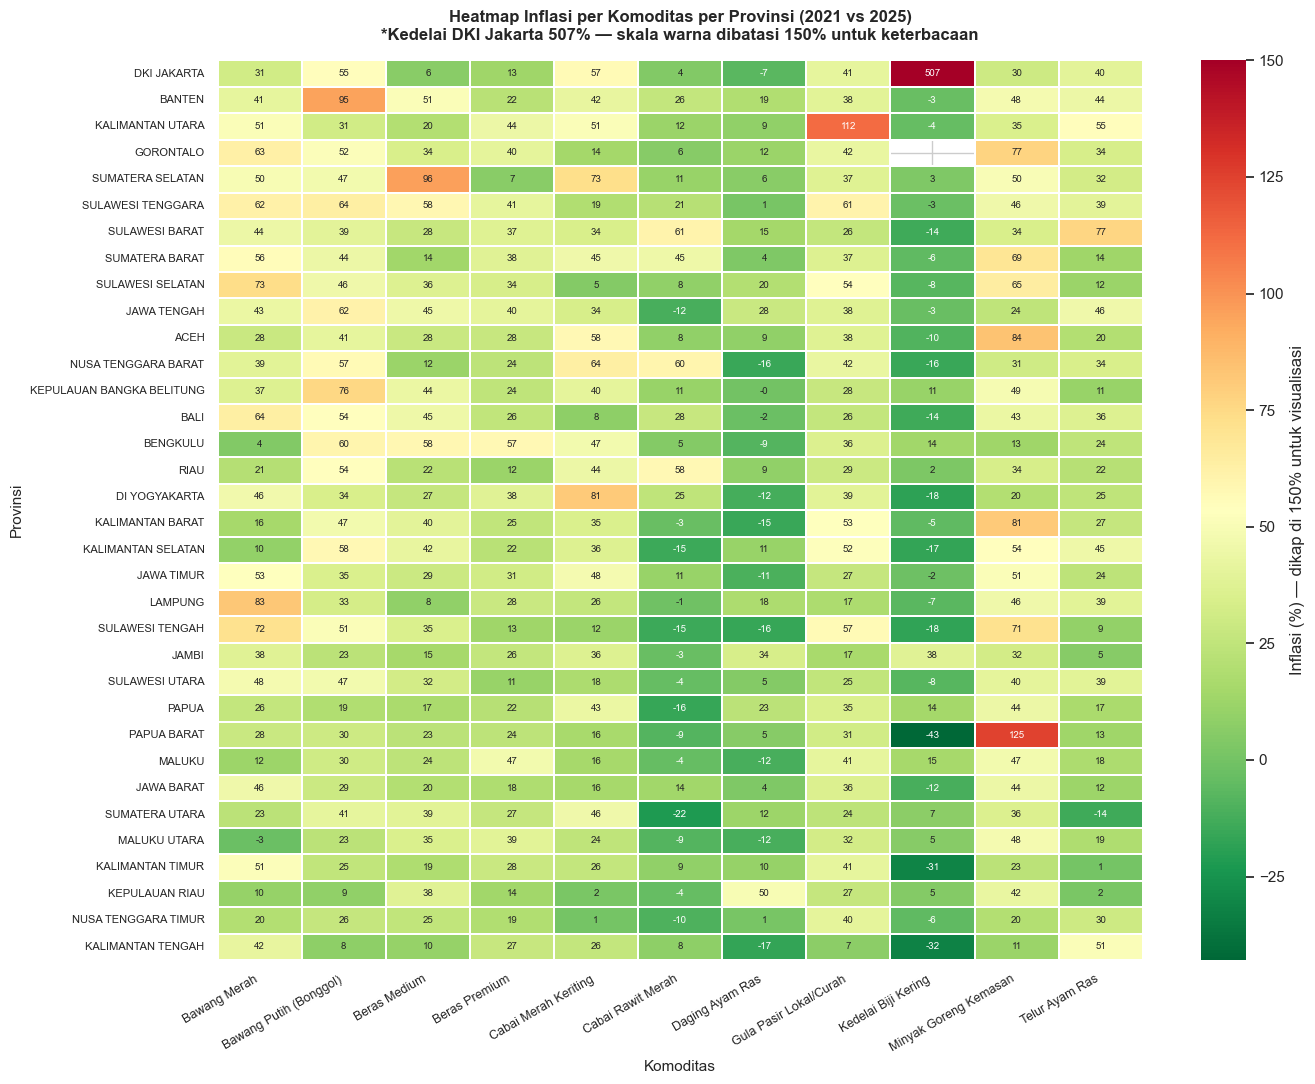

In [95]:
# Solusi: cap nilai inflasi di 150% untuk keperluan visualisasi
# Data aslinya tetap, hanya tampilannya yang dibatasi
heatmap_visual = heatmap_inflasi.copy()
heatmap_visual = heatmap_visual.clip(upper=150)

# Drop 4 provinsi Papua baru yang tidak punya data 2021
provinsi_drop = ['PAPUA BARAT DAYA', 'PAPUA PEGUNUNGAN', 'PAPUA SELATAN', 'PAPUA TENGAH']
heatmap_visual = heatmap_visual.drop(index=provinsi_drop, errors='ignore')

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(heatmap_visual,
            cmap='RdYlGn_r', annot=heatmap_inflasi.drop(index=provinsi_drop, errors='ignore'),
            fmt='.0f', linewidths=0.3,
            annot_kws={'size': 7}, cbar_kws={'label': 'Inflasi (%) — dikap di 150% untuk visualisasi'}, ax=ax)

ax.set_title('Heatmap Inflasi per Komoditas per Provinsi (2021 vs 2025)\n*Kedelai DKI Jakarta 507% — skala warna dibatasi 150% untuk keterbacaan',
             fontsize=12, fontweight='bold', pad=15)
ax.set_xlabel('Komoditas', fontsize=11)
ax.set_ylabel('Provinsi', fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=8)
plt.tight_layout()
plt.savefig('chart5_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [96]:
# Tabel 1 — Data mentah core (untuk tren & drill down)
df_core.to_csv('data_core.csv', index=False)

# Tabel 2 — Ringkasan inflasi (untuk overview)
ringkasan_core.reset_index().to_csv('ringkasan_inflasi.csv', index=False)

# Tabel 3 — Inflasi per komoditas
inflasi_komoditas['Inflasi_%'].reset_index().to_csv('inflasi_komoditas.csv', index=False)